# TCD stage-supervision sweep

This notebook aggregates the three seeds for each `stage mode × Decoder RF` condition and plots WBE and $P_{25}$ as mean $\pm$ one sample standard deviation.

By default, only points for which all three seeds are available are plotted. Set `PLOT_PARTIAL_RESULTS = True` only for an interim preview while experiments are still running.


In [27]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.container import ErrorbarContainer
import pandas as pd
from IPython.display import display


ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/experiments/v2.3/TCD_stage_mode/confirm"
)

OUTPUT_PDF = ROOT_DIR / "tcd_stage_mode_sweep.pdf"
OUTPUT_PNG = ROOT_DIR / "tcd_stage_mode_sweep.png"
OUTPUT_SUMMARY_CSV = (
    ROOT_DIR / "tcd_stage_mode_summary.csv"
)

SEEDS = [1234, 1235, 1236]
DECODER_RFS = [1, 5, 9, 13, 17]

# False: 세 seed가 모두 완료된 점만 사용 (논문용 기본값)
# True : 현재까지 완료된 seed만 평균하여 임시 확인
PLOT_PARTIAL_RESULTS = True


STEM_BASELINE_MODE = "first_only"
STEM_BASELINE_RF = 1

STAGE_MODE_ORDER = [
    # "geometric_w_st_0.5",
    "uniform",
    "geometric_w_st_2.0",
    "last_only",
]

STAGE_MODE_SPECS = {
    "first_only": {
        "label": r"$w_{\mathrm{st}}=0$",
        "color": "#666666",
        "linestyle": "--",
        "marker": None,
    },
    "geometric_w_st_0.5": {
        "label": r"$w_{\mathrm{st}}=0.5$",
        "color": "#56B4E9",
        "linestyle": "-",
        "marker": "o",
    },
    "uniform": {
        "label": r"$w_{\mathrm{st}}=1$ (uniform)",
        "color": "#009E73",
        "linestyle": "-",
        "marker": "o",
    },
    "geometric_w_st_2.0": {
        "label": r"$w_{\mathrm{st}}=2$",
        "color": "#E69F00",
        "linestyle": "-",
        "marker": "o",
    },
    "last_only": {
        "label": r"$w_{\mathrm{st}}=\infty$ (last-stage only)",
        "color": "#D55E00",
        "linestyle": "-",
        "marker": "o",
    },
}


DIR_PATTERN = re.compile(
    r"^stage_mode=(?P<stage_mode>.+?)_"
    + r"dec_RF=(?P<decoder_rf>\d+)_"
    + r"seed=(?P<seed>\d+)$"
)


In [28]:
def load_experiment_results(
    root_dir: Path,
) -> pd.DataFrame:
    if not root_dir.exists():
        raise FileNotFoundError(
            f"실험 디렉터리가 없습니다: {root_dir}"
        )

    records = []

    for experiment_dir in sorted(root_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        match = DIR_PATTERN.fullmatch(
            experiment_dir.name
        )

        if match is None:
            continue

        stage_mode = match.group("stage_mode")
        decoder_rf = int(match.group("decoder_rf"))
        seed = int(match.group("seed"))

        if stage_mode not in STAGE_MODE_SPECS:
            print(
                "[경고] 정의되지 않은 stage mode 제외:",
                experiment_dir.name,
            )
            continue

        if decoder_rf not in DECODER_RFS:
            continue

        if seed not in SEEDS:
            continue

        metric_path = experiment_dir / "eval_metrics.csv"

        if not metric_path.exists():
            print(
                "[대기] eval_metrics.csv 없음:",
                experiment_dir.name,
            )
            continue

        metric_df = pd.read_csv(metric_path)

        required_columns = {
            "word_boundary_error",
            "p_word_25ms",
        }
        missing_columns = (
            required_columns - set(metric_df.columns)
        )

        if missing_columns:
            raise ValueError(f"{metric_path}에 필요한 열이 없습니다: {sorted(missing_columns)}")
        row = metric_df.iloc[-1]

        records.append(
            {
                "stage_mode": stage_mode,
                "decoder_rf": decoder_rf,
                "seed": seed,
                # CSV의 WBE는 초 단위이므로 ms로 변환
                "wbe_ms": (
                    float(row["word_boundary_error"])
                    * 1000.0
                ),
                # p_word_25ms는 이미 percentage 단위
                "p25": float(row["p_word_25ms"]),
            }
        )

    return pd.DataFrame(records)


In [29]:
result_df = load_experiment_results(ROOT_DIR)

if result_df.empty:
    raise RuntimeError(
        f"완료된 eval_metrics.csv를 찾지 못했습니다: {ROOT_DIR}"
    )

result_df = (
    result_df
    .sort_values(
        ["stage_mode", "decoder_rf", "seed"]
    )
    .reset_index(drop=True)
)

display(result_df)
print(f"불러온 결과 수: {len(result_df)}")


,stage_mode,decoder_rf,seed,wbe_ms,p25
0,first_only,1,1234,18.214328,78.684646
1,first_only,1,1235,18.295266,77.797490
2,first_only,1,1236,18.465290,77.418971
3,geometric_w_st_2.0,1,1234,18.214328,78.684646
4,geometric_w_st_2.0,1,1235,18.295266,77.797490
5,geometric_w_st_2.0,1,1236,18.465290,77.418971
6,geometric_w_st_2.0,5,1234,17.529437,79.589546
7,geometric_w_st_2.0,5,1235,17.270701,79.749233
8,geometric_w_st_2.0,5,1236,17.763957,79.074997
9,geometric_w_st_2.0,9,1234,17.741654,79.063165


불러온 결과 수: 48


In [30]:
# first_only에서는 RF=1 결과만 stem baseline으로 사용
analysis_result_df = result_df[
    (
        result_df["stage_mode"]
        != STEM_BASELINE_MODE
    )
    | (
        result_df["decoder_rf"]
        == STEM_BASELINE_RF
    )
].copy()


summary_df = (
    analysis_result_df
    .groupby(
        ["stage_mode", "decoder_rf"],
        as_index=False,
    )
    .agg(
        seed_count=("seed", "nunique"),
        wbe_mean=("wbe_ms", "mean"),
        wbe_std=("wbe_ms", "std"),
        p25_mean=("p25", "mean"),
        p25_std=("p25", "std"),
    )
)


ALL_MODE_ORDER = [
    STEM_BASELINE_MODE,
    *STAGE_MODE_ORDER,
]

summary_df["stage_mode"] = pd.Categorical(
    summary_df["stage_mode"],
    categories=ALL_MODE_ORDER,
    ordered=True,
)

summary_df = (
    summary_df
    .sort_values(["stage_mode", "decoder_rf"])
    .reset_index(drop=True)
)


# Stem-only baseline: first_only, Decoder RF=1
stem_baseline_df = summary_df[
    (
        summary_df["stage_mode"]
        == STEM_BASELINE_MODE
    )
    & (
        summary_df["decoder_rf"]
        == STEM_BASELINE_RF
    )
]

if len(stem_baseline_df) != 1:
    raise ValueError(
        "Stem-only baseline 결과를 정확히 하나 찾지 못했습니다."
    )

stem_baseline = stem_baseline_df.iloc[0]

if stem_baseline["seed_count"] != len(SEEDS):
    raise ValueError(
        "Stem-only baseline에 세 seed가 모두 필요합니다."
    )


curve_summary_df = summary_df[
    summary_df["stage_mode"].isin(
        STAGE_MODE_ORDER
    )
].copy()

if PLOT_PARTIAL_RESULTS:
    plot_summary_df = curve_summary_df.copy()
else:
    plot_summary_df = curve_summary_df[
        curve_summary_df["seed_count"]
        == len(SEEDS)
    ].copy()

display(
    summary_df.round(
        {
            "wbe_mean": 3,
            "wbe_std": 3,
            "p25_mean": 3,
            "p25_std": 3,
        }
    )
)

print(
    "Stem-only baseline:"
    + f" WBE={stem_baseline['wbe_mean']:.3f}"
    + f" ± {stem_baseline['wbe_std']:.3f} ms,"
    + f" P25={stem_baseline['p25_mean']:.3f}"
    + f" ± {stem_baseline['p25_std']:.3f}%"
)

summary_df.to_csv(
    OUTPUT_SUMMARY_CSV,
    index=False,
)

,stage_mode,decoder_rf,seed_count,wbe_mean,wbe_std,p25_mean,p25_std
0,first_only,1,3,18.325,0.128,77.967,0.650
1,uniform,1,3,18.325,0.128,77.967,0.650
2,uniform,5,3,17.802,0.117,78.716,0.065
3,uniform,9,3,17.391,0.199,79.416,0.240
4,uniform,13,3,17.424,0.119,79.704,0.231
5,uniform,17,3,17.167,0.267,79.666,0.488
6,geometric_w_st_2.0,1,3,18.325,0.128,77.967,0.650
7,geometric_w_st_2.0,5,3,17.521,0.247,79.471,0.352
8,geometric_w_st_2.0,9,3,17.500,0.223,79.590,0.602
9,geometric_w_st_2.0,13,3,18.181,0.036,78.773,0.431


Stem-only baseline: WBE=18.325 ± 0.128 ms, P25=77.967 ± 0.650%


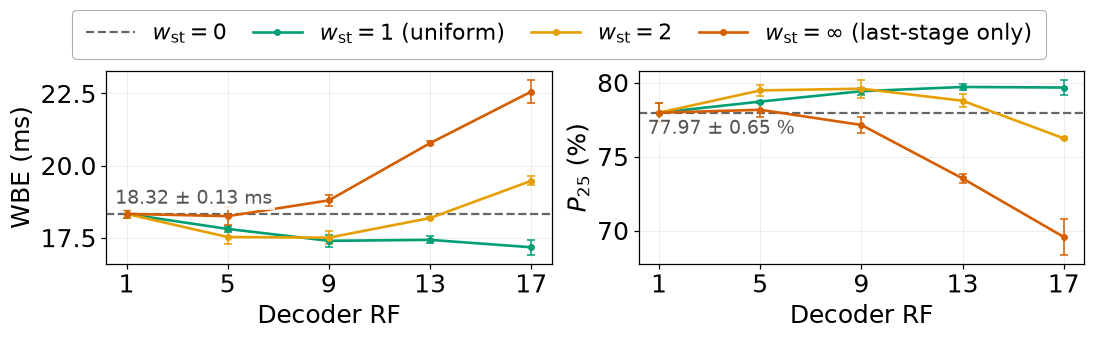

PDF 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.3/TCD_stage_mode/confirm/tcd_stage_mode_sweep.pdf
PNG 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.3/TCD_stage_mode/confirm/tcd_stage_mode_sweep.png


In [31]:
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 18
LEGEND_SIZE = 16


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10.8, 3.2),
    sharex=True,
)

metric_specs = [
    {
        "ax": axes[0],
        "mean_column": "wbe_mean",
        "std_column": "wbe_std",
        "ylabel": "WBE (ms)",
    },
    {
        "ax": axes[1],
        "mean_column": "p25_mean",
        "std_column": "p25_std",
        "ylabel": r"$P_{25}$ (%)",
    },
]

# ------------------------------------------------------------
# Stem-only horizontal baseline
# ------------------------------------------------------------

baseline_style = STAGE_MODE_SPECS[STEM_BASELINE_MODE]

for spec in metric_specs:
    ax = spec["ax"]

    baseline_mean = float(
        stem_baseline[spec["mean_column"]]
    )
    baseline_std = float(
        stem_baseline[spec["std_column"]]
    )

    unit = (
        "ms"
        if spec["mean_column"] == "wbe_mean"
        else "%"
    )

    ax.axhline(
        y=baseline_mean,
        color=baseline_style["color"],
        linestyle=baseline_style["linestyle"],
        label=baseline_style["label"],
        linewidth=1.6,
        zorder=2,
    )

    is_p25 = (
        spec["mean_column"] == "p25_mean"
    )

    text_offset_y = -5 if is_p25 else 4
    text_va = "top" if is_p25 else "bottom"

    ax.annotate(
        (
            f"{baseline_mean:.2f} "
            rf"$\pm$ {baseline_std:.2f} {unit}"
        ),
        xy=(0.02, baseline_mean),
        xycoords=(
            "axes fraction",
            "data",
        ),
        xytext=(0, text_offset_y),
        textcoords="offset points",
        ha="left",
        va=text_va,
        color="#555555",
        fontsize=13.5,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.85,
            "pad": 1.5,
        },
        zorder=5,
    )

for stage_mode in STAGE_MODE_ORDER:
    mode_df = (
        summary_df[
            summary_df["stage_mode"] == stage_mode
        ]
        .set_index("decoder_rf")
        .reindex(DECODER_RFS)
    )

    if mode_df["wbe_mean"].isna().all():
        continue

    style = STAGE_MODE_SPECS[stage_mode]

    for spec in metric_specs:
        yerr = (
            mode_df[spec["std_column"]]
            .fillna(0.0)
        )

        spec["ax"].errorbar(
            x=mode_df.index,
            y=mode_df[spec["mean_column"]],
            yerr=yerr,
            label=style["label"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=4.0,
            linewidth=1.9,
            elinewidth=1.1,
            capsize=3.0,
            capthick=1.1,
            zorder=3,
        )


for spec in metric_specs:
    ax = spec["ax"]

    ax.set_xlabel(
        "Decoder RF",
        fontsize=AXIS_LABEL_SIZE,
    )
    ax.set_ylabel(
        spec["ylabel"],
        fontsize=AXIS_LABEL_SIZE,
    )
    ax.set_xticks(DECODER_RFS)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        color="black",
        width=0.9,
    )

    ax.grid(
        axis="both",
        linestyle="-",
        linewidth=0.6,
        alpha=0.25,
        zorder=0,
    )

    # 첨부 노트북과 동일하게 검은 테두리를 유지
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.9)


handles, labels = axes[0].get_legend_handles_labels()

# 범례에는 점과 선만 표시하고, 그래프의 오차 막대는 유지
handles = [
    handle.lines[0]
    if isinstance(handle, ErrorbarContainer)
    else handle
    for handle in handles
]

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor="white",
    edgecolor="#B0B0B0",
    fontsize=LEGEND_SIZE,
    columnspacing=1.15,
    handlelength=2.2,
    borderpad=0.6,
    labelspacing=0.4,
)

legend.get_frame().set_linewidth(0.8)

fig.tight_layout(
    rect=(0, 0, 1, 0.90)
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"PDF 저장 완료: {OUTPUT_PDF}")
print(f"PNG 저장 완료: {OUTPUT_PNG}")
